# Tutorial 7: Two-Model Coupling

Estimated time: 25-40 minutes

## Prerequisites
No extra dependencies beyond base package runtime.

## Learning aims
- Primary package aim: build and sample a two-surrogate metamodel
- Secondary scientific aim: connect coupling constraints to the *induced joint posterior shape* — what the cloud looks like when two models are forced to agree

## Success criteria
- you can read a coupled-sample scatter and explain why it has the shape it does in terms of the spec's coupling kinds and σ values


## Why this tutorial matters

Two surrogates were trained independently — one says what `y` should be given `x`; the other says what `C` should be given some other inputs. Independently, their joint distribution is just a *product* — `p(y, C) = p(y) · p(C)` — no relationship between them. They live in different sub-systems and don't talk.

A **coupling** tells the metamodel that `y` and `C` are *the same physical quantity* (or related by a known transform). The joint must respect that. Sampling the coupled metamodel gives you draws from the joint posterior consistent with **both surrogate likelihoods AND the coupling constraint**. **The cloud you'll see in Step 2 is what "agreement" looks like** between two surrogates that were never trained together.

This is the central concept of the framework. Every tutorial after this one builds on it — T8 chains three couplings, T9's capstone wires your own surrogates from T5/T6 into the same shape.


## What surrogates are we coupling?

This tutorial uses two **pre-built example surrogates** that ship with the repo:

- `examples/coupled/artifacts/surrogate_A.artifact.json` — predicts `y` given `x`.
- `examples/coupled/artifacts/surrogate_B.artifact.json` — predicts `C` given some other input.

These are NOT the surrogates you trained in T5/T6 — they're toy examples sized to make the coupling lesson sharp. Treat them as black boxes for this notebook. (In Tutorial 9 you'll wire your *own* surrogates from T5/T6 into a structurally similar two-model spec — that's the capstone.)

The coupled metamodel spec is `tutorials/specs/metamodel.two_model.pymc.json`. Open it now in another window if you want to follow along; you'll edit its `sigma` field at the bottom of this notebook.


## Step 1: Build and sample metamodel


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


In [2]:
run_mm_cli('meta', 'build', 'tutorials/specs/metamodel.two_model.pymc.json')
run_mm_cli('meta', 'sample', 'tutorials/specs/metamodel.two_model.pymc.json', '--draws', '200', '--tune', '100', '--chains', '2', '--seed', '123')


$ bayesmm meta build tutorials/specs/metamodel.two_model.pymc.json
Metamodel IR artifact stored: artifact_id=7489a3bec1dc4b79a28a28e6338e38fe ir_path=tmp/metamodel_ir/7489a3bec1dc4b79a28a28e6338e38fe/ir.json
$ bayesmm meta sample tutorials/specs/metamodel.two_model.pymc.json --draws 200 --tune 100 --chains 2 --seed 123
Metamodel sample stored: sample_id=ccbab89fa50649d1993197d57d8b984a dataset=tmp/metamodel_samples/ccbab89fa50649d1993197d57d8b984a/samples_dataset.json


0

**Coupling kinds in this spec.** Open `tutorials/specs/metamodel.two_model.pymc.json` and look at the `couplings` array — there are two:

- `kind: "gaussian_link"` between `y` and `C`, with `sigma: 0.15`. **Probabilistic.** Reads as: "y and C should agree, with Gaussian noise of width σ=0.15 around the transform." Larger σ = looser coupling = wider cloud. This is what *shapes* the scatter you'll see.
- `kind: "deterministic"` between `C` and `z`, with affine transform `α=1, β=0`. **Hard constraint.** Reads as: `z = α·C + β` exactly — no noise. Under the hood the sampler enforces this with a sharp penalty for violations.

Watch which variable behaves which way: `C` is shaped by `y` through a probabilistic link (so `C` ends up as a noisy version of `y`), and `z` is then locked to `C` exactly (so `z` looks identical to `C` in the samples). The probabilistic kind shapes the cloud; the deterministic kind is the hard constraint that locks one variable to another.

(Implementation note: under the hood, *every* non-`deterministic` coupling kind compiles to the same Gaussian-noise primitive. T8 calls it `gaussian_link` too. Don't be surprised that the historical name `equality_soft` was identical — we picked one term for both notebooks.)


## Step 2: Visualize coupled samples (graphic)


**Predict before you look at the scatter.** Under the spec we just sampled (priors `y, C ~ Normal(0, 1)` with the `gaussian_link σ=0.15` between them):

- If we removed the coupling, the scatter would be a roughly circular cloud (uncorrelated `y` and `C`).
- With the coupling at `σ=0.15` (small), the scatter should compress along the `y = C` diagonal (because the link forces `C ≈ y`).
- Predict: how tight do you expect the diagonal to be? If we changed σ to `1.0`, would the diagonal vanish or just widen?

Hold those predictions, then run the cell.


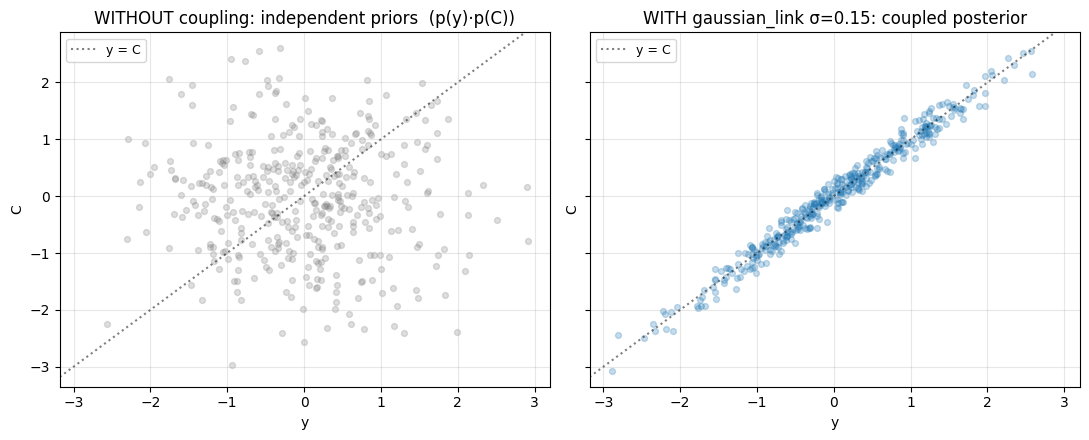


WITHOUT coupling: corr(y, C) = -0.042  (≈ 0)
WITH coupling   : corr(y, C) = 0.988  (close to 1; the coupling forces them to agree)
WITH coupling   : std(y - C) = 0.154  (close to σ=0.15 from the spec)


In [3]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# `root` came from bootstrap() at the top of the notebook.
reg = root / "tmp/metamodel_samples_registry.json"
payload = json.loads(reg.read_text())
# Sort by `created_at` (NOT by UUID-hex ordering, which is essentially random).
# Then filter to the most recent entry that actually contains the variables we need —
# the registry holds samples from many different metamodel specs.
candidates = sorted(
    [(meta.get("created_at", ""), sid, meta) for sid, meta in payload.items()],
    reverse=True,
)
chosen = None
for created, sid, meta in candidates:
    ds_candidate = Path(meta["samples_dataset_path"])
    if not ds_candidate.is_absolute():
        ds_candidate = root / ds_candidate
    if not ds_candidate.exists():
        continue
    ds_check = json.loads(ds_candidate.read_text())
    if "y" in ds_check["variables"] and "C" in ds_check["variables"]:
        chosen = (sid, ds_candidate)
        break
if chosen is None:
    raise RuntimeError(
        "No metamodel sample dataset with variables {y, C} found. "
        "Run Step 1 above first."
    )
latest_id, dataset_path = chosen
if not dataset_path.is_absolute():
    dataset_path = root / dataset_path
ds = json.loads(dataset_path.read_text())
vars_ = ds["variables"]

# Coupled samples from the metamodel
y = np.asarray(vars_["y"], dtype=float).reshape(-1)
c = np.asarray(vars_["C"], dtype=float).reshape(-1)

# A "no coupling" baseline: independent draws from the priors p(y) = p(C) = Normal(0,1).
# This is what the scatter would look like WITHOUT the gaussian_link.
rng = np.random.default_rng(42)
n_baseline = len(y)
y_prior = rng.normal(0, 1, size=n_baseline)
c_prior = rng.normal(0, 1, size=n_baseline)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)

# Left: no coupling (prior product)
axes[0].scatter(y_prior, c_prior, alpha=0.25, s=18, color="tab:gray")
axes[0].set_title("WITHOUT coupling: independent priors  (p(y)·p(C))")
axes[0].set_xlabel("y")
axes[0].set_ylabel("C")
axes[0].grid(True, alpha=0.3)
axes[0].axline((0, 0), slope=1, color="k", linestyle=":", alpha=0.5, label="y = C")
axes[0].legend(loc="upper left", fontsize=9)

# Right: with coupling
axes[1].scatter(y, c, alpha=0.25, s=18, color="tab:blue")
axes[1].set_title("WITH gaussian_link σ=0.15: coupled posterior")
axes[1].set_xlabel("y")
axes[1].set_ylabel("C")
axes[1].grid(True, alpha=0.3)
axes[1].axline((0, 0), slope=1, color="k", linestyle=":", alpha=0.5, label="y = C")
axes[1].legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

# Numeric correlation as a quick sanity check.
print(f"\nWITHOUT coupling: corr(y, C) = {np.corrcoef(y_prior, c_prior)[0,1]:.3f}  (≈ 0)")
print(f"WITH coupling   : corr(y, C) = {np.corrcoef(y, c)[0,1]:.3f}  (close to 1; the coupling forces them to agree)")
print(f"WITH coupling   : std(y - C) = {np.std(y - c):.3f}  (close to σ=0.15 from the spec)")


## Scientific checkpoint (active learning)

The single best way to internalize coupling is to vary `sigma` and see what changes.

1. Open `tutorials/specs/metamodel.two_model.pymc.json` and find the `gaussian_link` coupling between `y` and `C`. Note its current `sigma: 0.15`.
2. Change σ to **0.5**, save, and re-run the cells above (Step 1's `meta build` + `meta sample`, then the scatter).
3. Change σ to **1.0**, save, and re-run.
4. (Optional) Try σ = 0.05 — almost as tight as deterministic.

**Questions to answer for yourself**:

- At what σ does the coupling stop having visible effect? (You'll see the cloud become indistinguishable from the "without coupling" panel.)
- What does the `corr(y, C)` printout tell you about how strong the agreement is?
- Compare σ to the printed `std(y - C)`. They should be approximately equal at every σ — that's the spec's σ doing exactly what it promises.

**Reset σ to 0.15** when you're done so the spec matches what later tutorials might reference.


## Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| Coupling correlation near zero | The two surrogates aren't actually sharing a variable | Check the coupling block names a variable that exists in *both* specs — spelled identically. |
| `Surrogate artifact not found` | T5's fit never ran, or ran in another env | The metamodel consumes artifacts by reference; re-run T5 in the same kernel. |
| Metamodel samples but posterior looks like the prior | The data isn't constraining the coupled parameter | Widen the sweep, or check the coupling direction — an inverted link produces a well-formed, uninformative posterior. |
| Sampling is slow | Full Bayesian sampling over coupled surrogates | Reduce draws while exploring; raise them only for a result you intend to keep. |

**The failure worth internalising:** a metamodel that samples cleanly and returns
the prior is *not* an error — no exception, no warning, plausible output. Comparing
posterior against prior width is the only thing that catches it.

## Final check: T7's coupling actually shaped the joint

Asserts the latest samples_dataset.json with variables {y, C, z} has `corr(y, C) > 0.9`. The spec's `gaussian_link` with σ=0.15 SHOULD force them to nearly agree; if the correlation isn't there, the coupling primitive is broken or the wrong dataset was picked.

In [ ]:
# Self-check: T7's coupling actually correlates y and C in the joint posterior.
from pathlib import Path as _P
import json as _json
import numpy as _np
_reg = _json.loads((root / "tmp/metamodel_samples_registry.json").read_text())
# Pick the most recent dataset that contains {y, C} (registry has many; sort by created_at).
_candidates = sorted(
    [(meta.get("created_at", ""), sid, meta) for sid, meta in _reg.items()],
    reverse=True,
)
_chosen = None
for _created, _sid, _meta in _candidates:
    _ds = _P(_meta["samples_dataset_path"])
    if not _ds.is_absolute():
        _ds = root / _ds
    if not _ds.exists(): continue
    _data = _json.loads(_ds.read_text())
    if "y" in _data["variables"] and "C" in _data["variables"]:
        _chosen = _data
        break
assert _chosen is not None, "No metamodel samples dataset with variables {y, C} — T7's `meta sample` didn't run."
_y = _np.asarray(_chosen["variables"]["y"], dtype=float).reshape(-1)
_c = _np.asarray(_chosen["variables"]["C"], dtype=float).reshape(-1)
_corr = float(_np.corrcoef(_y, _c)[0, 1])
assert _corr > 0.9, (
    f"corr(y, C) = {_corr:.3f} — expected > 0.9 because the spec's `gaussian_link` "
    f"with σ=0.15 should force y ≈ C. Either the coupling didn't apply or the "
    f"wrong dataset was picked."
)
print(f"\n[T7 self-check OK] corr(y, C) = {_corr:.3f} > 0.9; coupling shaped the joint.")
